In [1]:
import pandas as pd

In [2]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [3]:
df = pd.read_csv("archive/HDFS_v1/preprocessed/anomaly_label.csv")
print(df.head())
print("Shape:", df.shape)

                    BlockId    Label
0  blk_-1608999687919862906   Normal
1   blk_7503483334202473044   Normal
2  blk_-3544583377289625738  Anomaly
3  blk_-9073992586687739851   Normal
4   blk_7854771516489510256   Normal
Shape: (575061, 2)


In [5]:
df["Label"].value_counts()

Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64

In [6]:
df["Label"].value_counts(normalize=True)*100

Label
Normal     97.071963
Anomaly     2.928037
Name: proportion, dtype: float64

In [ ]:
events = pd.read_csv("dataset/HDFS_v1/preprocessed/Event_occurrence_matrix.csv")
events.shape
events.head()

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0


In [10]:
merged = events.merge(df,on="BlockId")

In [11]:
merged.shape

(575061, 33)

In [12]:
merged.isnull().sum().sum()

np.int64(558223)

In [13]:
events.shape

(575061, 32)

In [14]:
df.shape

(575061, 2)

In [15]:
merged.shape

(575061, 33)

In [16]:
merged.isnull().sum().head()

BlockId         0
Label_x         0
Type       558223
E1              0
E2              0
dtype: int64

In [18]:
merged= events.merge(df,on="BlockId",how="inner")
merged.isnull().sum().sum()

np.int64(558223)

In [19]:
merged.isnull().sum().sort_values(ascending=False).head(10)

Type       558223
BlockId         0
E23             0
E17             0
E18             0
E19             0
E20             0
E21             0
E22             0
E24             0
dtype: int64

In [22]:
merged.isnull().sum().sum()

np.int64(0)

In [21]:
merged = merged.drop(columns =["Type"])

In [30]:
merged.iloc[:, 1:].sum().describe()

count       31
unique      30
top       7002
freq         2
dtype: int64

In [24]:
events.iloc[:, 1:].sum().describe()

count       31
unique      30
top       7002
freq         2
dtype: int64

In [31]:
merged.iloc[:, 1:].describe()

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
count,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,...,575061.000000,575061.000000,575061.0,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000,575061.000000
mean,0.000017,0.208736,0.745531,0.619425,2.996607,0.012341,0.005940,0.000085,2.967536,0.000188,...,0.009642,2.438084,1.0,2.427871,0.000007,0.012176,2.990537,0.001695,0.002240,0.000082
std,0.005897,0.580644,2.517178,1.604554,0.220913,0.146923,0.080642,0.009779,0.310178,0.018926,...,0.101269,1.184490,0.0,1.182648,0.002637,0.140481,0.408638,0.041183,0.048865,0.009230
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000,...,0.000000,3.000000,1.0,3.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000,...,0.000000,3.000000,1.0,3.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,0.000000,...,0.000000,3.000000,1.0,3.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
max,2.000000,4.000000,203.000000,41.000000,13.000000,10.000000,5.000000,2.000000,3.000000,3.000000,...,3.000000,13.000000,1.0,10.000000,1.000000,5.000000,13.000000,2.000000,4.000000,2.000000


In [27]:
df["Label"] = df["Label"].map({"Normal": 0, "Anomaly": 1})

In [28]:
df["Label"].value_counts()

Label
0    558223
1     16838
Name: count, dtype: int64

In [29]:
df["Label"].value_counts()

Label
0    558223
1     16838
Name: count, dtype: int64

In [34]:
from sklearn.model_selection import train_test_split
x = merged.drop(["BlockId", "Label_y"], axis=1)
y = merged["Label_y"]
y = y.map({"Normal": 0, "Anomaly": 1})
x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=0.2, stratify = y, random_state=42
)

In [33]:
print(merged.columns)

Index(['BlockId', 'Label_x', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8',
       'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18',
       'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28',
       'E29', 'Label_y'],
      dtype='object')


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")

In [41]:
df.shape
df.head()

,BlockId,Label
0,blk_-1608999687919862906,0
1,blk_7503483334202473044,0
2,blk_-3544583377289625738,1
3,blk_-9073992586687739851,0
4,blk_7854771516489510256,0


In [42]:
events.shape
events.head()

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0


In [43]:
merged.shape
merged.head()

,BlockId,Label_x,E1,E2,E3,E4,E5,E6,E7,E8,...,E21,E22,E23,E24,E25,E26,E27,E28,E29,Label_y
0,blk_-1608999687919862906,Success,0,0,203,0,10,7,0,0,...,10,1,10,0,4,10,0,0,0,Normal
1,blk_7503483334202473044,Success,0,2,1,0,3,0,0,0,...,3,1,3,0,0,3,0,0,0,Normal
2,blk_-3544583377289625738,Fail,0,0,203,0,3,0,0,0,...,3,1,3,0,0,3,0,0,0,Anomaly
3,blk_-9073992586687739851,Success,0,3,0,0,3,0,0,0,...,3,1,3,0,0,3,0,0,0,Normal
4,blk_7854771516489510256,Success,0,3,1,15,3,0,0,0,...,3,1,3,0,0,3,0,0,0,Normal


In [45]:
merged.isnull().sum()
#events.isnull().sum()

BlockId    0
Label_x    0
E1         0
E2         0
E3         0
E4         0
E5         0
E6         0
E7         0
E8         0
E9         0
E10        0
E11        0
E12        0
E13        0
E14        0
E15        0
E16        0
E17        0
E18        0
E19        0
E20        0
E21        0
E22        0
E23        0
E24        0
E25        0
E26        0
E27        0
E28        0
E29        0
Label_y    0
dtype: int64

In [47]:
merged = merged.drop(columns = ["Label_x"])
merged = merged.rename(columns = {"Label_y":"Label"})


In [48]:
merged.head()

,BlockId,E1,E2,E3,E4,E5,E6,E7,E8,E9,...,E21,E22,E23,E24,E25,E26,E27,E28,E29,Label
0,blk_-1608999687919862906,0,0,203,0,10,7,0,0,3,...,10,1,10,0,4,10,0,0,0,Normal
1,blk_7503483334202473044,0,2,1,0,3,0,0,0,3,...,3,1,3,0,0,3,0,0,0,Normal
2,blk_-3544583377289625738,0,0,203,0,3,0,0,0,3,...,3,1,3,0,0,3,0,0,0,Anomaly
3,blk_-9073992586687739851,0,3,0,0,3,0,0,0,3,...,3,1,3,0,0,3,0,0,0,Normal
4,blk_7854771516489510256,0,3,1,15,3,0,0,0,3,...,3,1,3,0,0,3,0,0,0,Normal


In [49]:
merged["Label"] = merged["Label"].map({"Normal": 0, "Anomaly": 1})

In [50]:
merged["Label"].value_counts()

Label
0    558223
1     16838
Name: count, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split
x = merged.drop(["BlockId", "Label"], axis=1)
y = merged["Label"]
#y = y.map({"Normal": 0, "Anomaly": 1})
x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=0.2, stratify = y, random_state=42
)

In [52]:
print(x_train.shape)
print(x_test.shape)

(460048, 29)
(115013, 29)


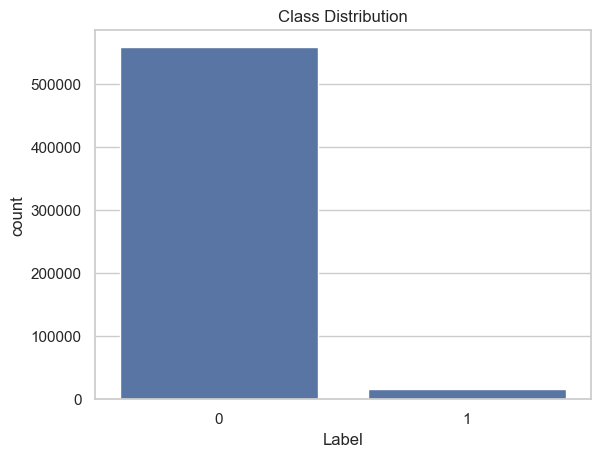

In [54]:
sns.countplot(x="Label",data=merged)
plt.title("Class Distribution")
plt.show()

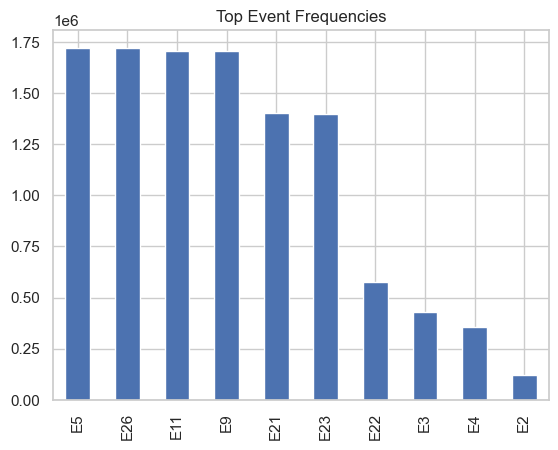

In [56]:
events_sum=x.sum()
events_sum.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Event Frequencies")
plt.show()


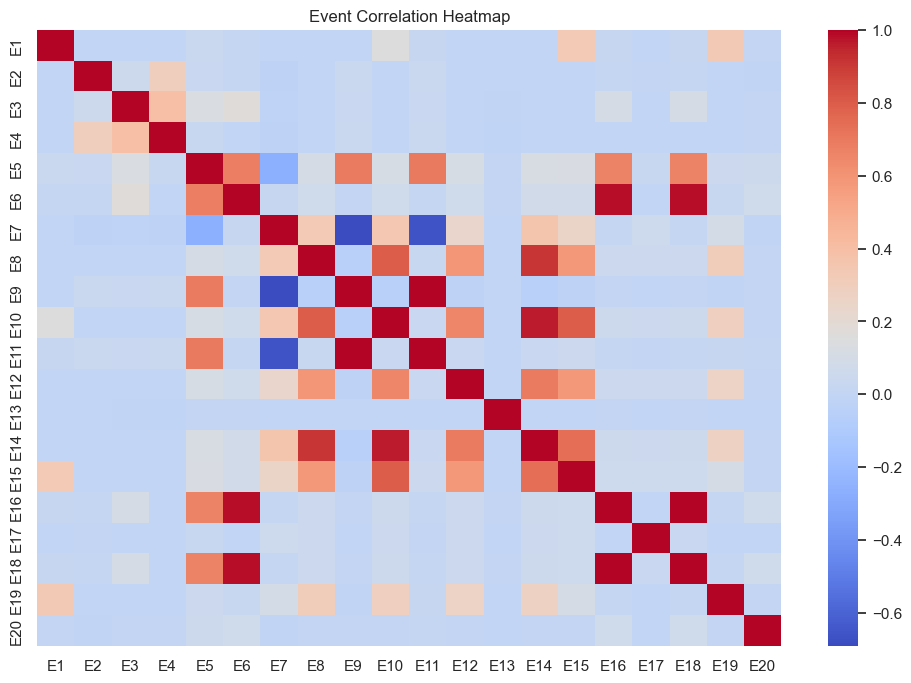

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(x.iloc[:, :20].corr(), cmap="coolwarm")
plt.title("Event Correlation Heatmap")
plt.show()

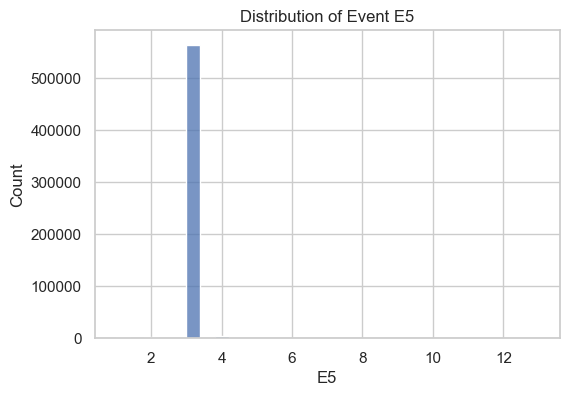

In [59]:
plt.figure(figsize=(6,4))
sns.histplot(merged["E5"], bins=30)
plt.title("Distribution of Event E5")
plt.show()

In [61]:
event_sums = events.iloc[:,1:].sum()

event_sums.sort_values(ascending=False).head(10)
event_sums.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Most Frequent Events")
plt.show()

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

In [65]:
'''We want to see how frequently certain events occur and how their values are distributed.
Choose a few events (for example the most frequent ones).
Find top events first'''
event_sums = x.sum()

event_sums.sort_values(ascending=False).head(10)

E5     1723232
E26    1719741
E11    1706679
E9     1706514
E21    1402047
E23    1396174
E22     575061
E3      428726
E4      356207
E2      120036
dtype: int64

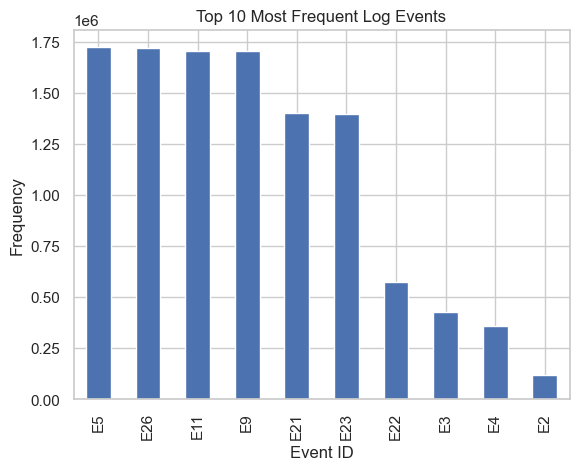

In [66]:
'''What this tells you
You will see:
which events occur very frequently
which events are rare
whether distributions are skewed
This is important for anomaly detection.'''
top_events = x.sum().sort_values(ascending=False).head(10)

top_events.plot(kind="bar")

plt.title("Top 10 Most Frequent Log Events")
plt.xlabel("Event ID")
plt.ylabel("Frequency")
plt.show()

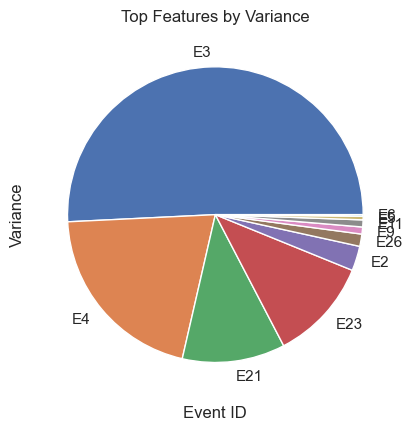

In [68]:
'''Variance tells us how much a feature changes.
Features with very low variance carry little information.
Compute variance'''
variance = x.var()
variance.sort_values().head(10)
#This shows lowest variance features.

variance.sort_values(ascending=False).head(10).plot(kind="pie")

plt.title("Top Features by Variance")
plt.xlabel("Event ID")
plt.ylabel("Variance")

plt.show()


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_filtered = selector.fit_transform(X)

X_filtered.shape

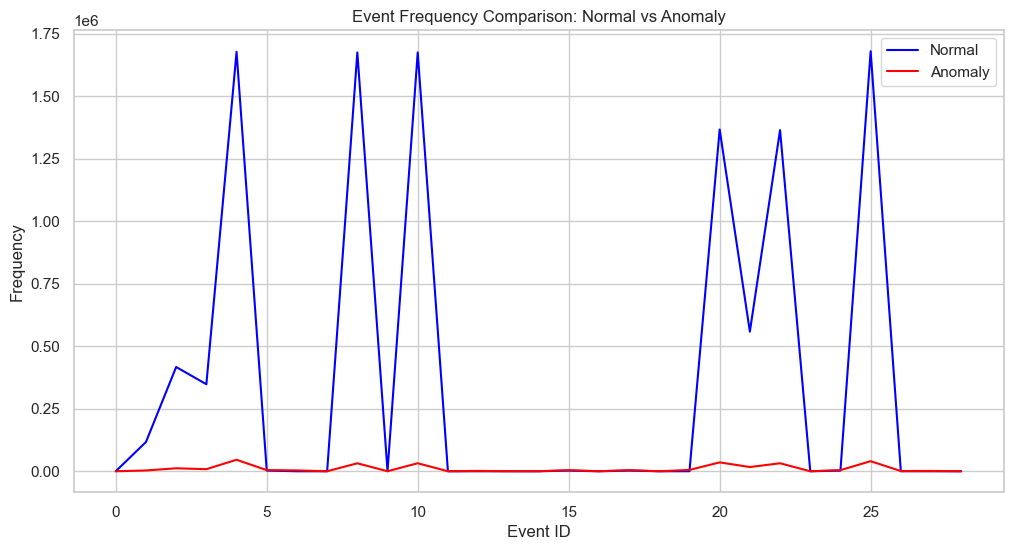

In [70]:
normal_logs = merged[merged["Label"] == 0]
anomaly_logs = merged[merged["Label"] == 1]
normal_event_counts = normal_logs.drop(["BlockId","Label"], axis=1).sum()
anomaly_event_counts = anomaly_logs.drop(["BlockId","Label"], axis=1).sum()
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(normal_event_counts.values, label="Normal", color="blue")
plt.plot(anomaly_event_counts.values, label="Anomaly", color="red")

plt.title("Event Frequency Comparison: Normal vs Anomaly")
plt.xlabel("Event ID")
plt.ylabel("Frequency")

plt.legend()

plt.show()
'''This shows how event frequencies differ between normal and anomalous blocks.
It is very common in papers like DeepLog, LogBERT, LogAnomaly.'''

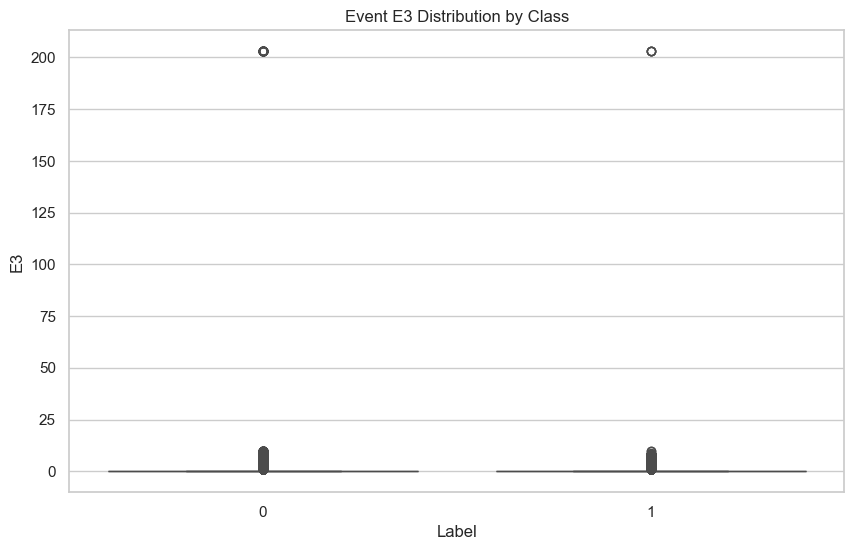

In [71]:
'''Replace E3 with any event.
This shows if an event behaves differently in anomalies.'''
plt.figure(figsize=(10,6))

sns.boxplot(x="Label", y="E3", data=merged)

plt.title("Event E3 Distribution by Class")
plt.show()

In [72]:
merged.to_csv("processed_hdfs.csv", index=False)